In [1]:
import kagglehub
import shutil

# Download dataset
path = kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")

# Define target directory in /content
target_path = "/content/augmented-alzheimer-mri-dataset"

# Move the dataset to /content
shutil.move(path, target_path)

print("Dataset moved to:", target_path)


100%|██████████| 380M/380M [00:03<00:00, 128MB/s]

Extracting files...


Dataset moved to: /content/augmented-alzheimer-mri-dataset


In [3]:
# Cell 1: Import Necessary Libraries and set random seed
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd
from PIL import Image
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)


In [4]:
# Cell 2: Define Dataset Paths for Augmented Data
augmented_dataset_path = "/content/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset"

# Folder names exactly as in your dataset:
classes = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

# Verify each path exists:
for cls in classes:
    folder = os.path.join(augmented_dataset_path, cls)
    assert os.path.exists(folder), f"Path {folder} does not exist."


In [5]:
# Define path for the original dataset (for later evaluation)
original_dataset_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset"
for cls in classes:
    folder = os.path.join(original_dataset_path, cls)
    assert os.path.exists(folder), f"Path {folder} does not exist."


In [6]:
# Cell 3: Define Resize with Padding Transformation and other transforms
class ResizeWithPadding:
    def __init__(self, target_size):
        self.target_size = target_size  # (height, width)

    def __call__(self, image):
        original_size = image.size  # (width, height)
        ratio = min(self.target_size[1] / original_size[0], self.target_size[0] / original_size[1])
        new_size = (int(original_size[0] * ratio), int(original_size[1] * ratio))
        image = image.resize(new_size, Image.Resampling.LANCZOS)
        new_image = Image.new("L", self.target_size, color=0)  # Black background for padding
        paste_position = ((self.target_size[1] - new_size[0]) // 2,
                          (self.target_size[0] - new_size[1]) // 2)
        new_image.paste(image, paste_position)
        return new_image

transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [7]:
# Cell 4: Define Custom Dataset for 4 classes
class AlzheimerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        # Define class names and corresponding labels (order matters)
        self.class_names = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
        for label, cls in enumerate(self.class_names):
            folder = os.path.join(root_dir, cls)
            assert os.path.exists(folder), f"Path {folder} does not exist."
            for img_name in os.listdir(folder):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff")):
                    self.image_paths.append(os.path.join(folder, img_name))
                    self.labels.append(label)
        self.data_frame = pd.DataFrame({
            "image_path": self.image_paths,
            "label": self.labels
        })

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_path = self.data_frame.iloc[idx, 0]
        label = self.data_frame.iloc[idx, 1]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, label


In [8]:
# Cell 5: Define Siamese Dataset that returns a pair and the target distance
class SiameseAlzheimerDataset(Dataset):
    def __init__(self, subset, alpha=1.0):
        self.subset = subset
        self.alpha = alpha  # scaling factor for target distance

    def __getitem__(self, index):
        img1, label1 = self.subset[index]
        # Randomly pick another sample from the same subset
        index2 = np.random.choice(range(len(self.subset)))
        img2, label2 = self.subset[index2]
        target = self.alpha * abs(label1 - label2)  # desired distance
        return img1, img2, torch.tensor([target], dtype=torch.float32)

    def __len__(self):
        return len(self.subset)


In [9]:
# Cell 6: Define Capsule Layers
class PrimaryCapsules(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, num_capsules, capsule_dim):
        super(PrimaryCapsules, self).__init__()
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        batch_size = x.size(0)
        out = self.relu(self.conv(x))
        out = out.view(batch_size, self.num_capsules, self.capsule_dim, -1)
        out = out.permute(0, 3, 1, 2).contiguous()
        out = out.view(batch_size, -1, self.capsule_dim)
        return self.squash(out)

    def squash(self, tensor, dim=-1):
        squared_norm = (tensor ** 2).sum(dim=dim, keepdim=True)
        scale = squared_norm / (1 + squared_norm)
        return scale * tensor / torch.sqrt(squared_norm + 1e-8)

class DigitCapsules(nn.Module):
    def __init__(self, num_capsules, in_capsules, in_dim, out_dim, num_iterations=3):
        super(DigitCapsules, self).__init__()
        self.num_capsules = num_capsules
        self.num_iterations = num_iterations
        self.W = nn.Parameter(0.01 * torch.randn(1, in_capsules, num_capsules, out_dim, in_dim))

    def forward(self, x):
        batch_size = x.size(0)
        x = x.unsqueeze(2).unsqueeze(4)
        W = self.W.repeat(batch_size, 1, 1, 1, 1)
        u_hat = torch.matmul(W, x).squeeze(-1)
        b_ij = torch.zeros(batch_size, x.size(1), self.num_capsules, 1, device=x.device)
        for iteration in range(self.num_iterations):
            c_ij = F.softmax(b_ij, dim=2)
            s_j = (c_ij * u_hat).sum(dim=1, keepdim=True)
            v_j = self.squash(s_j, dim=-1)
            agreement = (u_hat * v_j).sum(dim=-1, keepdim=True)
            b_ij = b_ij + agreement
        return v_j.squeeze(1)

    def squash(self, tensor, dim=-1):
        squared_norm = (tensor ** 2).sum(dim=dim, keepdim=True)
        scale = squared_norm / (1 + squared_norm)
        return scale * tensor / torch.sqrt(squared_norm + 1e-8)


In [10]:
# Cell 7: Define the Capsule Network
class CapsuleNetwork(nn.Module):
    def __init__(self, weights=None, num_classes=4):
        super(CapsuleNetwork, self).__init__()
        self.num_classes = num_classes
        # Use ResNet18 as backbone, adjusting first conv layer for grayscale input.
        self.cnn = models.resnet18(weights=weights)
        self.cnn.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.cnn = nn.Sequential(*list(self.cnn.children())[:-2])
        self.primary_capsules = PrimaryCapsules(
            in_channels=512,
            out_channels=256,
            kernel_size=3,
            stride=1,
            padding=1,
            num_capsules=32,
            capsule_dim=8
        )
        self.digit_capsules = DigitCapsules(
            num_capsules=self.num_classes,
            in_capsules=32 * 7 * 7,
            in_dim=8,
            out_dim=16
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.primary_capsules(x)
        x = self.digit_capsules(x)
        # Instead of returning the raw capsule vectors, we take their norms.
        # This yields a vector of length num_classes.
        embeddings = x.norm(dim=-1)
        return embeddings


In [11]:
# Cell 8: Define the Siamese Capsule Network for Regression on distance
class SiameseCapsuleNetwork(nn.Module):
    def __init__(self, weights=models.ResNet18_Weights.IMAGENET1K_V1, num_classes=4):
        super(SiameseCapsuleNetwork, self).__init__()
        self.capsule_net = CapsuleNetwork(weights=weights, num_classes=num_classes)

    def forward(self, x1, x2):
        emb1 = self.capsule_net(x1)  # shape: [batch, num_classes]
        emb2 = self.capsule_net(x2)
        # Compute Euclidean distance between the two embeddings
        distance = torch.norm(emb1 - emb2, dim=1, keepdim=True)
        return distance


In [12]:
# Cell 9: Initialize the Augmented Dataset and DataLoaders
full_dataset = AlzheimerDataset(root_dir=augmented_dataset_path, transform=transform)

train_indices, test_indices = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    random_state=42,
    stratify=full_dataset.data_frame["label"]
)

train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)

train_siamese = SiameseAlzheimerDataset(train_subset, alpha=1.0)
test_siamese = SiameseAlzheimerDataset(test_subset, alpha=1.0)

train_loader = DataLoader(train_siamese, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_siamese, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
# Cell 10: Device Configuration and Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = SiameseCapsuleNetwork(weights=models.ResNet18_Weights.IMAGENET1K_V1, num_classes=4).to(device)


Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


In [16]:
# Cell 11: Training Loop
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 12
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_idx, (img1, img2, targets) in enumerate(train_loader):
        img1, img2, targets = img1.to(device), img2.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(img1, img2)  # predicted distance, shape: [batch, 1]
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (batch_idx + 1) % 10 == 0:
            avg_loss = running_loss / 10
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {avg_loss:.4f}')
            train_losses.append(avg_loss)
            running_loss = 0.0

    # Evaluate on test set (MSE)
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for img1, img2, targets in test_loader:
            img1, img2, targets = img1.to(device), img2.to(device), targets.to(device)
            outputs = model(img1, img2)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    avg_test_loss = total_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Test MSE Loss: {avg_test_loss:.4f}\n')


Epoch [1/12], Step [10/1700], Loss: 0.8089
Epoch [1/12], Step [20/1700], Loss: 0.9045
Epoch [1/12], Step [30/1700], Loss: 0.8745
Epoch [1/12], Step [40/1700], Loss: 0.8553
Epoch [1/12], Step [50/1700], Loss: 0.9328
Epoch [1/12], Step [60/1700], Loss: 0.7965
Epoch [1/12], Step [70/1700], Loss: 0.9522
Epoch [1/12], Step [80/1700], Loss: 0.8448
Epoch [1/12], Step [90/1700], Loss: 0.8172
Epoch [1/12], Step [100/1700], Loss: 0.6678
Epoch [1/12], Step [110/1700], Loss: 0.7757
Epoch [1/12], Step [120/1700], Loss: 0.9940
Epoch [1/12], Step [130/1700], Loss: 0.8089
Epoch [1/12], Step [140/1700], Loss: 0.8521
Epoch [1/12], Step [150/1700], Loss: 0.7867
Epoch [1/12], Step [160/1700], Loss: 0.8418
Epoch [1/12], Step [170/1700], Loss: 0.8836
Epoch [1/12], Step [180/1700], Loss: 0.7810
Epoch [1/12], Step [190/1700], Loss: 0.7056
Epoch [1/12], Step [200/1700], Loss: 0.6566
Epoch [1/12], Step [210/1700], Loss: 0.6630
Epoch [1/12], Step [220/1700], Loss: 0.7140
Epoch [1/12], Step [230/1700], Loss: 0.66

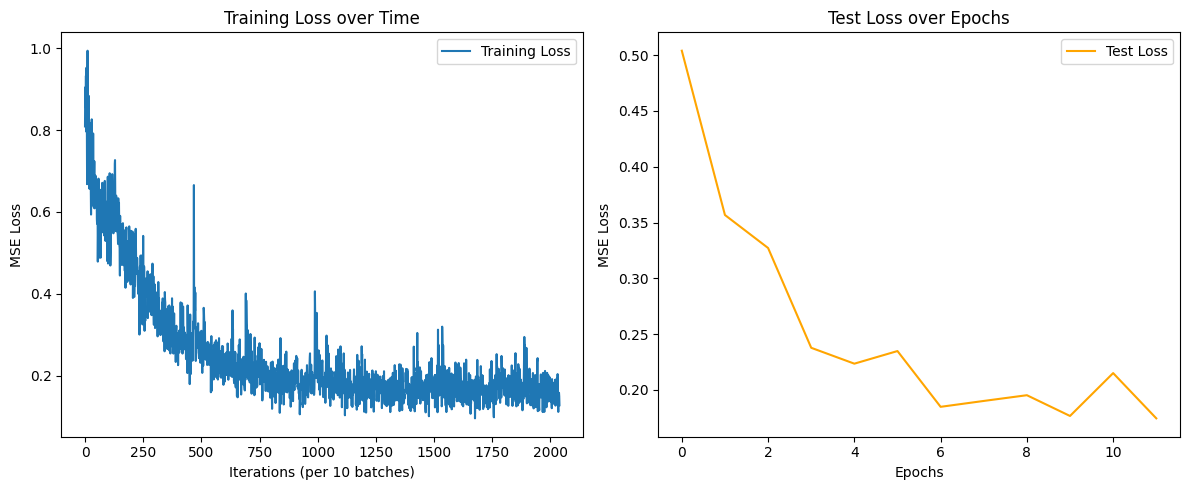

In [17]:
# Cell 12: Plot Training Loss and Test Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Iterations (per 10 batches)')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Time')
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_losses, label='Test Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Test Loss over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


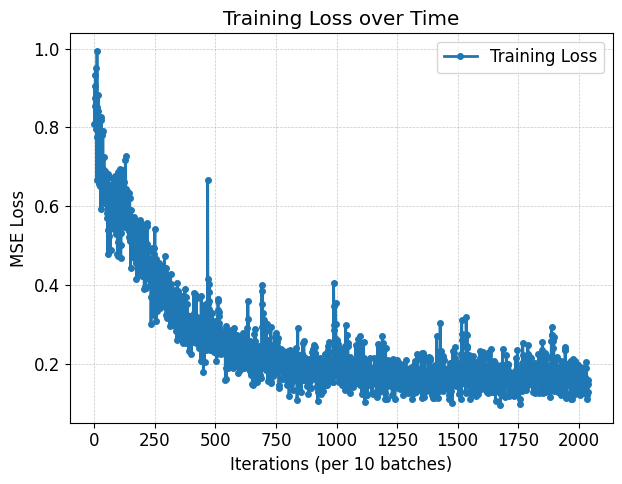

In [34]:
import matplotlib.pyplot as plt

# Optional: Set font
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

plt.figure(figsize=(12,5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.xlabel('Iterations (per 10 batches)')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Test Loss
# plt.subplot(1,2,2)
# plt.plot(test_losses, label='Test Loss', color='orange', linewidth=2, marker='s', markersize=4)
# plt.xlabel('Epochs')
# plt.ylabel('MSE Loss')
# plt.title('Test Loss over Epochs')
# plt.legend()
# plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

# Save for draw.io (high-res, transparent background)
plt.savefig('loss_plot4.png', dpi=600, bbox_inches='tight', transparent=True)
plt.savefig('loss_plot4.pdf', bbox_inches='tight')  # vector version

plt.show()


In [18]:
# Cell 13: Save the Trained Model
model_save_path = 'siamese_capsule_alzheimer_4class.pth'
torch.save(model.state_dict(), model_save_path)
print(f'Model saved to {model_save_path}')


Model saved to siamese_capsule_alzheimer_4class.pth


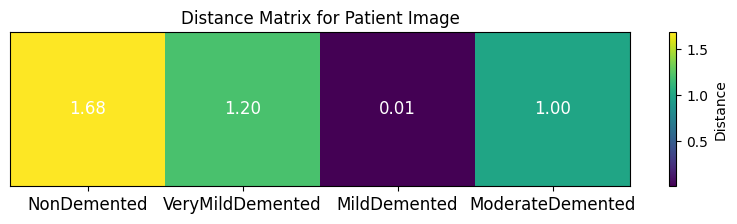

In [ ]:
# Cell 14: Evaluate a Manually Provided Image and Plot 1x4 Distance Matrix with Numeric Values

from PIL import Image

# Ensure original dataset is available for class names and representatives
original_dataset = AlzheimerDataset(root_dir=original_dataset_path, transform=transform)

# Manually specify your image path here:
manual_image_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/MildDemented/26 (19).jpg"  # Change this to your image path

# Load and preprocess the manually provided image
manual_image = Image.open(manual_image_path).convert("L")
manual_image = transform(manual_image)  # Apply the same transforms as training
manual_image_tensor = manual_image.unsqueeze(0).to(device)

# For each class, pick a representative image from the original dataset
representatives = {}
for cls in range(4):
    indices = original_dataset.data_frame.index[original_dataset.data_frame["label"] == cls].tolist()
    if len(indices) > 0:
        representatives[cls] = original_dataset[indices[0]][0].unsqueeze(0)  # Add batch dimension

# Compute embeddings for each representative image
model.eval()
rep_embeddings = {}
with torch.no_grad():
    for cls in representatives:
        rep_embeddings[cls] = model.capsule_net(representatives[cls].to(device))  # shape: [1, 4]

# Compute the embedding for the manually provided image
with torch.no_grad():
    manual_embedding = model.capsule_net(manual_image_tensor)  # shape: [1, 4]

# Compute Euclidean distances between the manual image embedding and each representative embedding
distances = []
for cls in range(4):
    rep_emb = rep_embeddings[cls]
    distance = torch.norm(manual_embedding - rep_emb, dim=1).item()
    distances.append(distance)

# Plot a 1x4 matrix with the computed distances and numeric values shown in each cell
plt.figure(figsize=(10,2))
ax = plt.gca()
ax.set_xticks(range(4))
ax.set_xticklabels(original_dataset.class_names, fontsize=12)
ax.set_yticks([])

# Create a matrix using the distances
matrix = np.array([distances])
im = ax.imshow(matrix, cmap='viridis', aspect='auto')

# Annotate each cell with the numeric distance value
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="white", fontsize=12)

plt.title("Distance Matrix for Patient Image")
plt.colorbar(im, ax=ax, label="Distance")
plt.show()


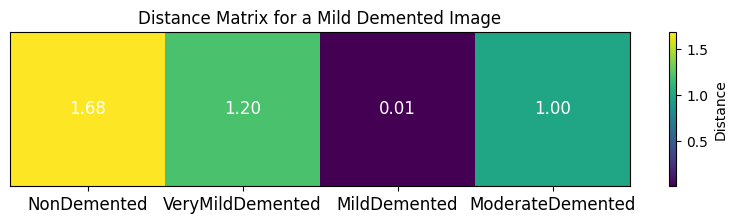

High-quality distance matrix saved as distance_matrix_high_quality.png.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Cell 15: Save the Distance Matrix Figure in High Quality for Publication

import os

# Recreate the distance matrix figure using the 'distances' list from Cell 14
fig, ax = plt.subplots(figsize=(10, 2))
ax.set_xticks(range(4))
ax.set_xticklabels(original_dataset.class_names, fontsize=12)
ax.set_yticks([])

# Create a matrix from the distances and display it
matrix = np.array([distances])
im = ax.imshow(matrix, cmap='viridis', aspect='auto')

# Annotate each cell with its numeric distance value
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="white", fontsize=12)

plt.title("Distance Matrix for a Mildb Demented Image")
plt.colorbar(im, ax=ax, label="Distance")

# Save the figure with high DPI for publication quality
output_filename = "distance_matrix_high_quality.png"
fig.savefig(output_filename, dpi=600, bbox_inches='tight')
plt.show()

print(f"High-quality distance matrix saved as {output_filename}.")

# If running in Google Colab, attempt to download the file automatically.
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    print("Download is not supported in this environment. Please manually download the file from the current working directory.")


Classification Report:
                  precision    recall  f1-score   support

     NonDemented       1.00      0.76      0.86      3200
VeryMildDemented       0.73      1.00      0.84      2240
    MildDemented       0.98      0.94      0.96       896
ModerateDemented       1.00      1.00      1.00        64

        accuracy                           0.87      6400
       macro avg       0.93      0.92      0.92      6400
    weighted avg       0.90      0.87      0.87      6400



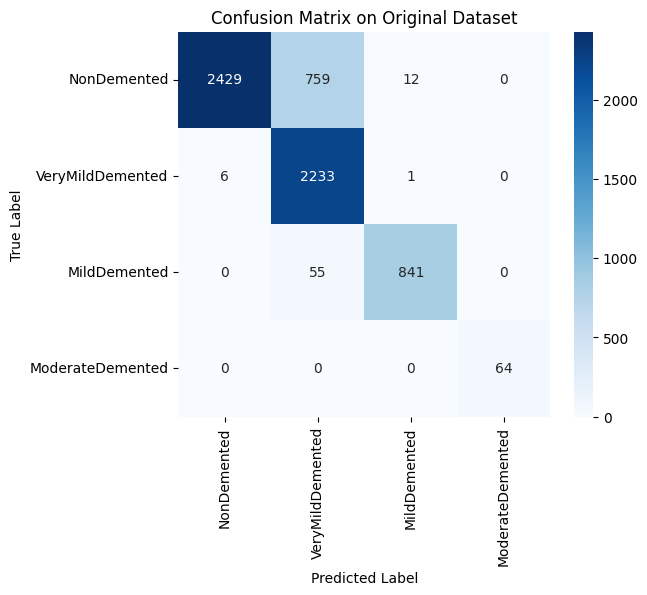

In [21]:
# Cell 15: Evaluate on the Full Original Dataset and Plot the Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Create the original dataset (using same transformation for consistency)
original_dataset = AlzheimerDataset(root_dir=original_dataset_path, transform=transform)

# For each class, pick a representative image (the first image encountered)
representatives = {}
for cls in range(4):
    indices = original_dataset.data_frame.index[original_dataset.data_frame["label"] == cls].tolist()
    if len(indices) > 0:
        # Get representative image and unsqueeze to add batch dimension
        representatives[cls] = original_dataset[indices[0]][0].unsqueeze(0)

# Move representatives to device and compute their embeddings
model.eval()
rep_embeddings = {}
with torch.no_grad():
    for cls in representatives:
        rep_tensor = representatives[cls].to(device)
        rep_embeddings[cls] = model.capsule_net(rep_tensor)  # shape: [1, 4]

# For each image in the original dataset, compute the embedding and distances to each representative
all_true_labels = []
all_pred_labels = []
with torch.no_grad():
    for idx in range(len(original_dataset)):
        image, true_label = original_dataset[idx]
        image_tensor = image.unsqueeze(0).to(device)
        test_embedding = model.capsule_net(image_tensor)  # shape: [1, 4]

        # Compute Euclidean distances to each class representative
        distances = []
        for cls in range(4):
            rep_emb = rep_embeddings[cls]  # shape: [1, 4]
            distance = torch.norm(test_embedding - rep_emb, dim=1).item()
            distances.append(distance)

        # Predicted label is the one with minimum distance
        pred_label = np.argmin(distances)
        all_true_labels.append(true_label)
        all_pred_labels.append(pred_label)

# Compute confusion matrix and classification report
cm = confusion_matrix(all_true_labels, all_pred_labels)
report = classification_report(all_true_labels, all_pred_labels, target_names=original_dataset.class_names)

print("Classification Report:")
print(report)

# Plot confusion matrix using a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=original_dataset.class_names,
            yticklabels=original_dataset.class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix on Original Dataset")
plt.show()


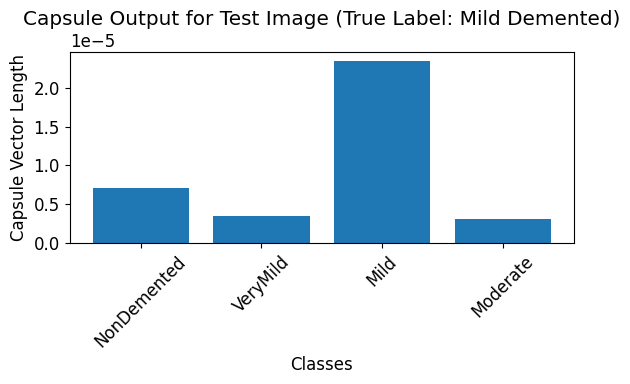

In [66]:
import matplotlib.pyplot as plt
import torch

# Set model to evaluation mode
model.eval()

# Select a specific test image (e.g., from DataLoader or dataset directly)
# Let's assume 'test_image' is shape: [1, 1, 224, 224] (grayscale)
test_image = original_dataset[15][0].unsqueeze(0).to(device)  # adjust index as needed
true_label = original_dataset[15][1]

# Pass through the CapsuleNetwork (not the Siamese network)
with torch.no_grad():
    capsule_lengths = model.capsule_net(test_image)  # Output shape: [1, num_classes]

# Convert to 1D numpy array for plotting
lengths = capsule_lengths.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(6,4))
plt.bar(range(len(lengths)), lengths)
plt.xticks(range(len(lengths)), ['NonDemented', 'VeryMild', 'Mild', 'Moderate'], rotation=45)
plt.xlabel('Classes')
plt.ylabel('Capsule Vector Length')
plt.title(f'Capsule Output for Test Image (True Label: Mild Demented)')
plt.tight_layout()
plt.savefig(f'capsule_lengths_test_sample_Mild{true_label}.png', dpi=300)
plt.show()